In [25]:
%run PREPROCESS.py

--------------------------------------------------------------------------------
Beginning Merging Individual Datasets, Complete Dataset...
--------------------------------------------------------------------------------
Step 1: Loading all datasets...
Step 2: Standardizing dates...
Step 3: Merging all data layers...
Step 4: Filling weekend gaps for market data...
--------------------------------------------------------------------------------
SUCCESS: datasets/COMPLETE_DATASET.csv is ready.
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 82120 entries, 172 to 82024
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ServiceStationName  82120 non-null  object        
 1   Address             82120 non-null  object        
 2   Suburb              82120 non-null  object        
 3   Postcode            82120 non-n

## (2) Training...

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
# Optional: make plots display inline in Jupyter
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') # clean plot style

In [2]:
df = pd.read_csv('datasets/fuel/fuelcheck_pricehistory_2026_02.csv')
# ── Inspect ───────────────────────────────────────────────────────────────
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nFirst rows:')
df.head()

Shape: (66981, 8)

Column types:
ServiceStationName     object
Address                object
Suburb                 object
Postcode                int64
Brand                  object
FuelCode               object
PriceUpdatedDate       object
Price                 float64
dtype: object

Missing values:
ServiceStationName    0
Address               0
Suburb                0
Postcode              0
Brand                 0
FuelCode              0
PriceUpdatedDate      0
Price                 0
dtype: int64

First rows:


,ServiceStationName,Address,Suburb,Postcode,Brand,FuelCode,PriceUpdatedDate,Price
0,Medco Waratah,"36 LORNA ST, WARATAH NSW 2298",WARATAH,2298,Independent,E10,2026-02-01 00:05:31,148.5
1,Medco Waratah,"36 LORNA ST, WARATAH NSW 2298",WARATAH,2298,Independent,DL,2026-02-01 00:05:31,162.5
2,Speedway Sunnyholt,"162 Sunnyholt Rd, Blacktown NSW 2148",Blacktown,2148,Speedway,E10,2026-02-01 00:07:43,173.5
3,Speedway Sunnyholt,"162 Sunnyholt Rd, Blacktown NSW 2148",Blacktown,2148,Speedway,U91,2026-02-01 00:07:43,175.5
4,Speedway Sunnyholt,"162 Sunnyholt Rd, Blacktown NSW 2148",Blacktown,2148,Speedway,P98,2026-02-01 00:07:43,194.5


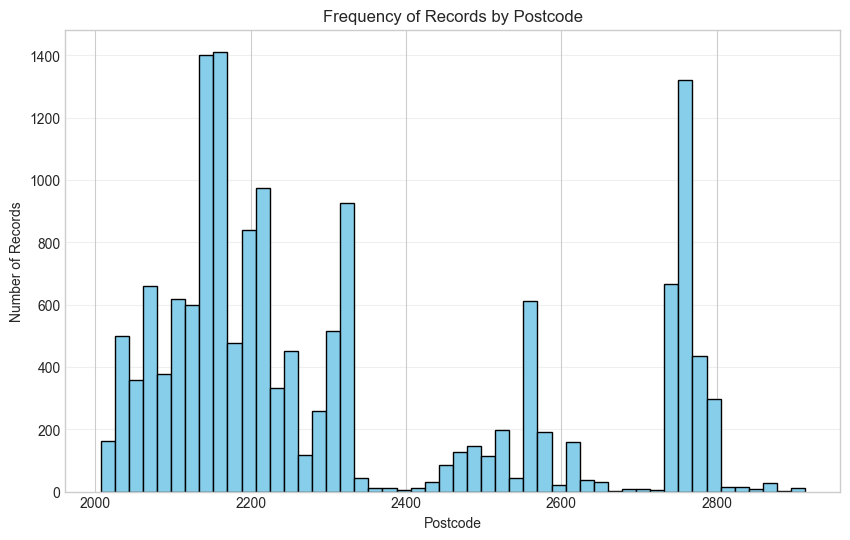

In [3]:
# Convert pandas objects to python strings for better interpretation
df['FuelCode'] = df['FuelCode'].astype(str)
df['Suburb'] = df['Suburb'].astype(str).str.lower()

# And filter so that is only E10 rows
df = df[df['FuelCode'] == "E10"].copy()

# And filter so that is only the relevant postcodes (<= 3000)
df = df[df['Postcode'] <= 3000]

# And show how many E10 data we have per postcode in this range
plt.figure(figsize=(10, 6))
plt.hist(df['Postcode'], bins=50, color='skyblue', edgecolor='black')
plt.title('Frequency of Records by Postcode')
plt.xlabel('Postcode')
plt.ylabel('Number of Records')
plt.grid(axis='y', alpha=0.3)

plt.show()

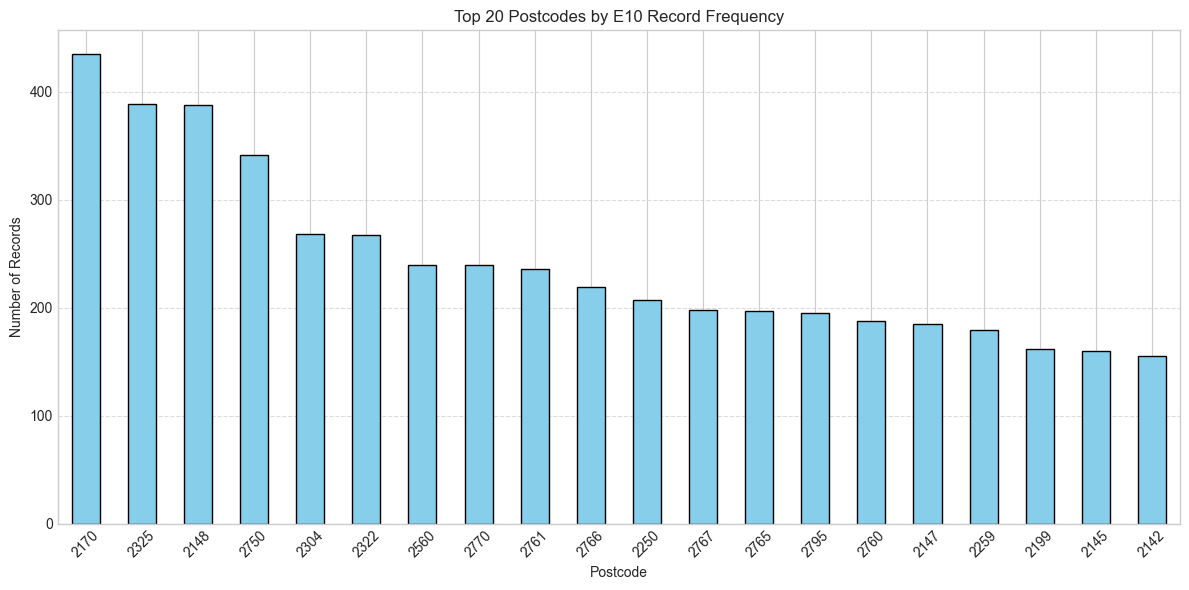

In [4]:
# That is useful, but it'll be even better to see directly which postcodes
# have the most data available.
top_postcodes = df['Postcode'].value_counts().head(20)

# Plot as a Bar Chart
plt.figure(figsize=(12, 6))
top_postcodes.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 20 Postcodes by E10 Record Frequency')
plt.xlabel('Postcode')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

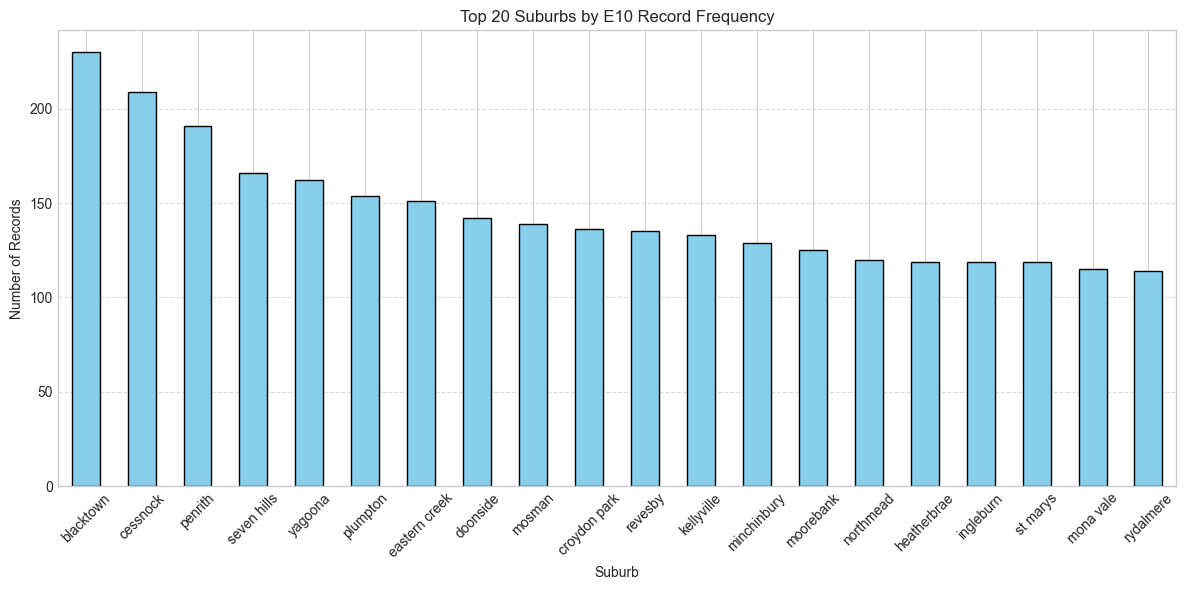

In [5]:
# Let's have the x-axis be Suburb instead; does it work?
top_suburbs = df['Suburb'].value_counts().head(20)

# Plot as a Bar Chart
plt.figure(figsize=(12, 6))
top_suburbs.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Top 20 Suburbs by E10 Record Frequency')
plt.xlabel('Suburb')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
# For now, let's only focus on only these top 20 postcodes
df = df[df['Postcode'].isin(top_postcodes.index)].copy()

# As expected, only 20 postcodes remaining
print(f"New shape: {df.shape}")
print(f"Unique postcodes remaining: {df['Postcode'].nunique()}")
print(df.head())

New shape: (4849, 8)
Unique postcodes remaining: 20
        ServiceStationName                                            Address  \
2       Speedway Sunnyholt               162 Sunnyholt Rd, Blacktown NSW 2148   
5     7-Eleven Minchinbury   1042 Great Western Highway, Minchinbury NSW 2770   
7     7-Eleven Minchinbury  Lot 3 Great Western Highway (Cnr John Hines Av...   
13        7-Eleven Colyton  104 Great Western Highway & Bennett Road, Coly...   
23  7-Eleven Eastern Creek  Lot 16 - 25 Great Western Highway, Eastern Cre...   

           Suburb  Postcode     Brand FuelCode     PriceUpdatedDate  Price  
2       blacktown      2148  Speedway      E10  2026-02-01 00:07:43  173.5  
5     minchinbury      2770  7-Eleven      E10  2026-02-01 00:33:12  186.9  
7     minchinbury      2770  7-Eleven      E10  2026-02-01 00:33:12  176.9  
13        colyton      2760  7-Eleven      E10  2026-02-01 00:36:10  174.9  
23  eastern creek      2766  7-Eleven      E10  2026-02-01 00:39:12  186.9  

In [ ]:
e10_count = df[df["FuelCode"] == "E10"].shape[0]
print(e10_count)

4849


: 

In [27]:
# 1. Extract feature importances
importances = model.feature_importances_
feature_names = X.columns

# 2. Create a clean DataFrame for viewing
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance Ranking ---")
print(feature_importance_df)


--- Feature Importance Ranking ---
                Feature  Importance
1                 price    0.669870
8    postcode_daily_avg    0.140068
9   postcode_rolling_7d    0.041217
0              postcode    0.036148
3              temp_min    0.013292
2              temp_max    0.011986
11      oil_price_lag_7    0.011375
6            tgp_sydney    0.010043
12     tgp_sydney_lag_1    0.009812
13     tgp_sydney_lag_7    0.009216
7               aud_usd    0.008678
15        aud_usd_lag_7    0.008604
14        aud_usd_lag_1    0.006730
5             oil_price    0.006394
10      oil_price_lag_1    0.006175
4              rainfall    0.005444
16          day_of_week    0.004947


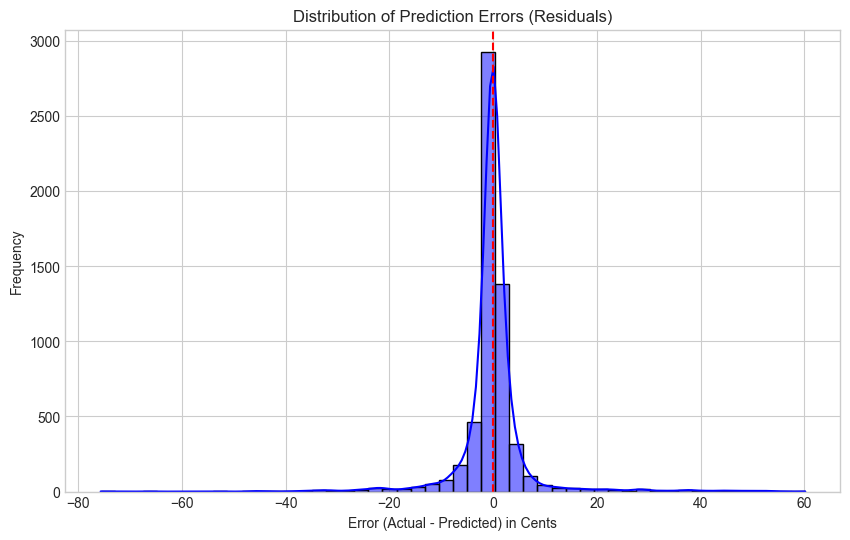

In [28]:
residuals = y_test - predictions
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50, color='blue')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error (Actual - Predicted) in Cents')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()

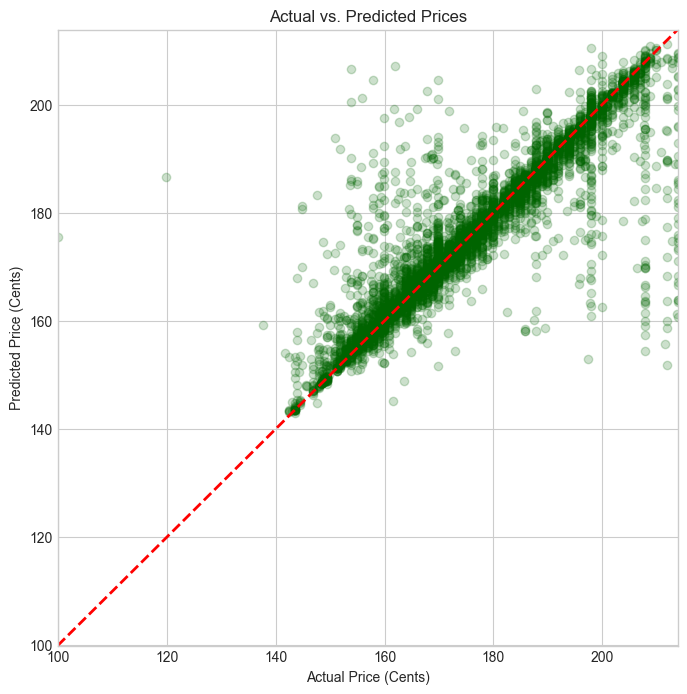

In [29]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.2, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices')
# Tighten the limits to see the "core" of the data
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.xlabel('Actual Price (Cents)')
plt.ylabel('Predicted Price (Cents)')
plt.show()

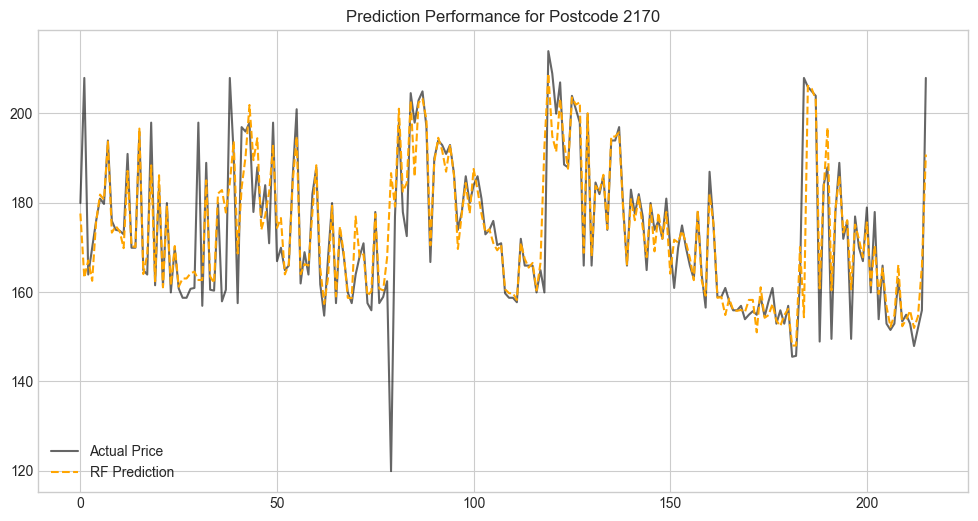

In [30]:
# Create a small dataframe for the test results
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = predictions

# Pick one postcode to visualize (e.g., the most common one)
sample_postcode = test_results['postcode'].mode()[0]
sample_data = test_results[test_results['postcode'] == sample_postcode].sort_index()

plt.figure(figsize=(12, 6))
plt.plot(sample_data['actual'].values, label='Actual Price', color='black', alpha=0.6)
plt.plot(sample_data['predicted'].values, label='RF Prediction', color='orange', linestyle='--')
plt.title(f'Prediction Performance for Postcode {sample_postcode}')
plt.legend()
plt.show()

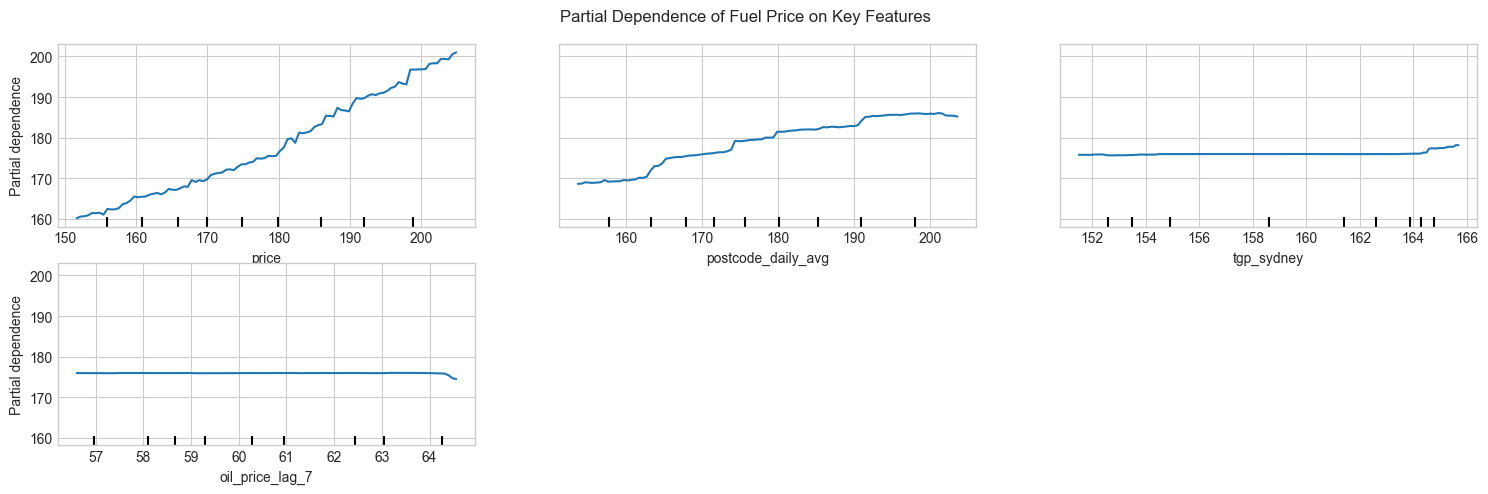

In [31]:
from sklearn.inspection import PartialDependenceDisplay

# Choose the top 3-4 features from your importance list
features_to_plot = ['price', 'postcode_daily_avg', 'tgp_sydney', 'oil_price_lag_7']

fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(model, X_train, features_to_plot, ax=ax)
plt.suptitle('Partial Dependence of Fuel Price on Key Features')
plt.tight_layout()
plt.show()

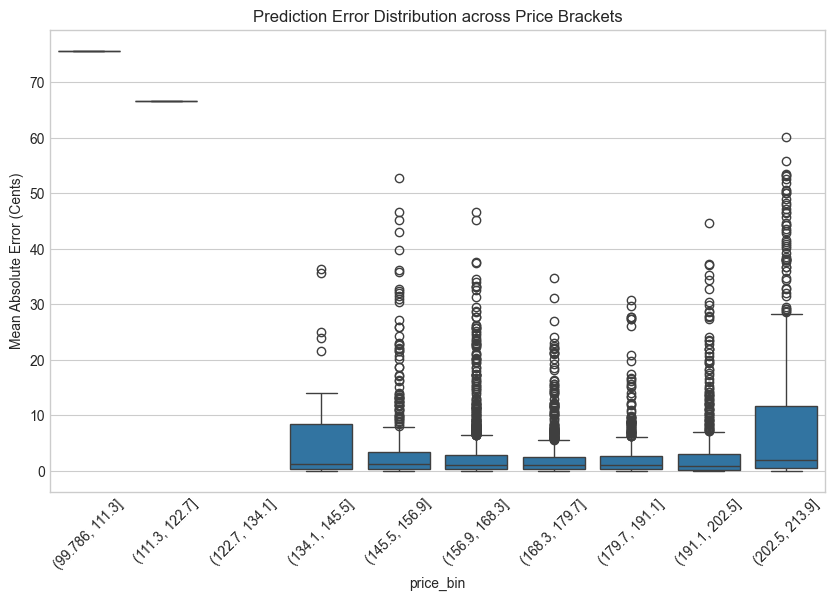

In [32]:
test_results = pd.DataFrame({'actual': y_test, 'predicted': predictions})
test_results['error'] = (test_results['actual'] - test_results['predicted']).abs()

# Bin the prices into $0.10 increments
test_results['price_bin'] = pd.cut(test_results['actual'], bins=10)

plt.figure(figsize=(10, 6))
sns.boxplot(x='price_bin', y='error', data=test_results)
plt.xticks(rotation=45)
plt.title('Prediction Error Distribution across Price Brackets')
plt.ylabel('Mean Absolute Error (Cents)')
plt.show()

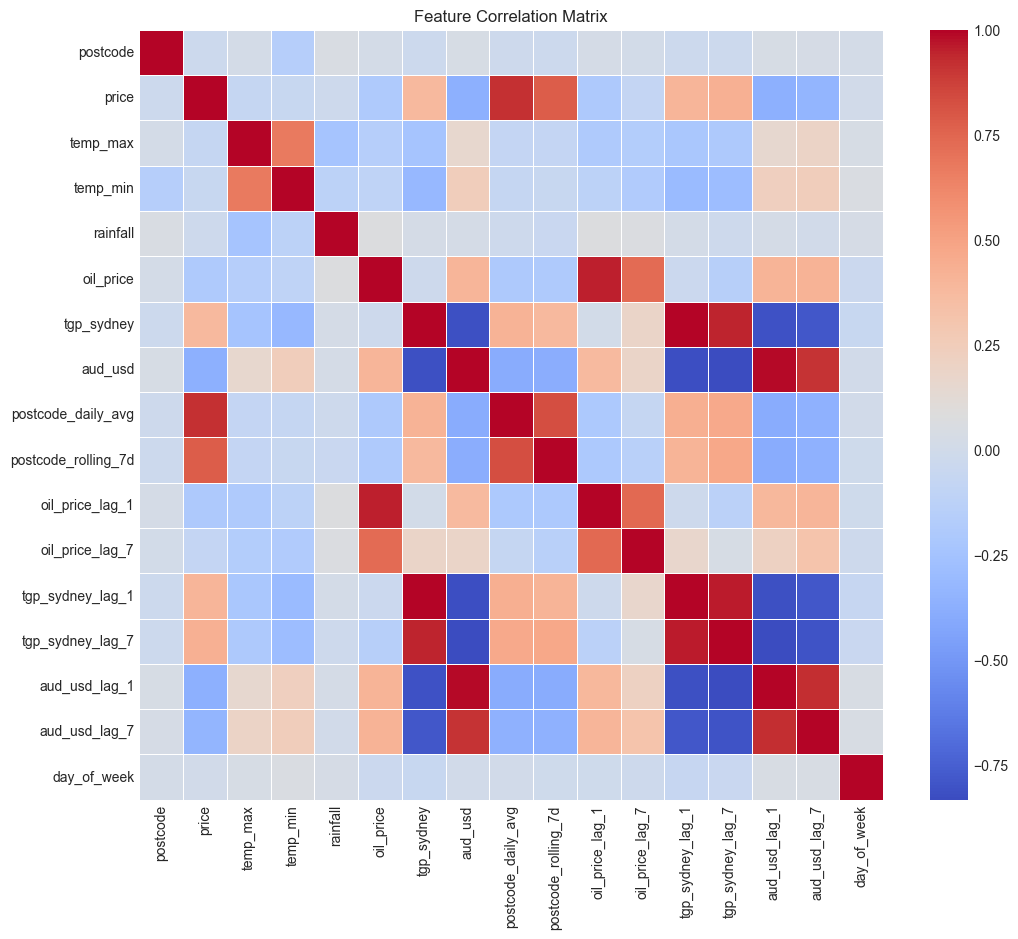

In [33]:
plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

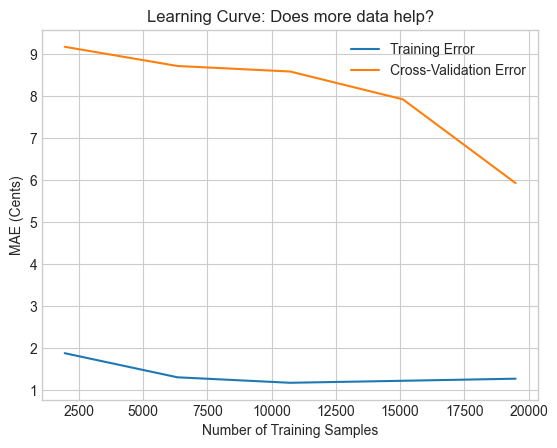

In [34]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=20, n_jobs=-1), X, y, cv=3, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_absolute_error'
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Cross-Validation Error')
plt.title('Learning Curve: Does more data help?')
plt.xlabel('Number of Training Samples')
plt.ylabel('MAE (Cents)')
plt.legend()
plt.show()